In [43]:
import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------------
# Load all ABSA result JSONs and flatten into a single DataFrame
# ---------------------------------------------------------------------------

RESULTS_DIR = os.path.join("results", "absa")
SUBREDDITS = [
    # "ChatGPT",
    "MyBoyfriendIsAI",
    "MyGirlfriendIsAI"]

rows = []

for subreddit in SUBREDDITS:
    pattern = os.path.join(RESULTS_DIR, subreddit, "*.json")
    for filepath in sorted(glob.glob(pattern)):
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)

        post_id = data["post_id"]

        # --- Post-level sentiments ---
        post_absa = data.get("post_absa", {})
        for aspect in ("ai", "human"):
            if aspect in post_absa:
                rows.append({
                    "subreddit": subreddit,
                    "post_id": post_id,
                    "source": "post",
                    "aspect": aspect,
                    "sentiment": post_absa[aspect],
                })

        # --- Comment-level sentiments ---
        for comment in data.get("comments_absa", []):
            for aspect in ("ai", "human"):
                if aspect in comment:
                    rows.append({
                        "subreddit": subreddit,
                        "post_id": post_id,
                        "source": "comment",
                        "comment_id": comment["comment_id"],
                        "aspect": aspect,
                        "sentiment": comment[aspect],
                    })

df = pd.DataFrame(rows)
print(f"Total sentiment observations: {len(df)}")
print(f"\nBreakdown by subreddit:")
print(df.groupby(["subreddit", "aspect", "sentiment"]).size().unstack(fill_value=0))
df.head(10)

Total sentiment observations: 1952

Breakdown by subreddit:
sentiment                negative  neutral  positive
subreddit        aspect                             
MyBoyfriendIsAI  ai           356       82       677
                 human        139       16       236
MyGirlfriendIsAI ai            47       18       251
                 human         41        5        84


,subreddit,post_id,source,aspect,sentiment,comment_id
0,MyBoyfriendIsAI,1rdlaah,post,ai,negative,NaN
1,MyBoyfriendIsAI,1rdlaah,comment,ai,negative,o760z7h
2,MyBoyfriendIsAI,1rdlaah,comment,ai,neutral,o762dst
3,MyBoyfriendIsAI,1rdlaah,comment,ai,positive,o77dum5
4,MyBoyfriendIsAI,1rdlaah,comment,ai,positive,o76wvs3
5,MyBoyfriendIsAI,1rdojd4,post,ai,positive,NaN
6,MyBoyfriendIsAI,1rdojd4,post,human,negative,NaN
7,MyBoyfriendIsAI,1rdojd4,comment,ai,positive,o79p6xb
8,MyBoyfriendIsAI,1rdojd4,comment,ai,positive,o781hrd
9,MyBoyfriendIsAI,1rdojd4,comment,human,neutral,o781hrd


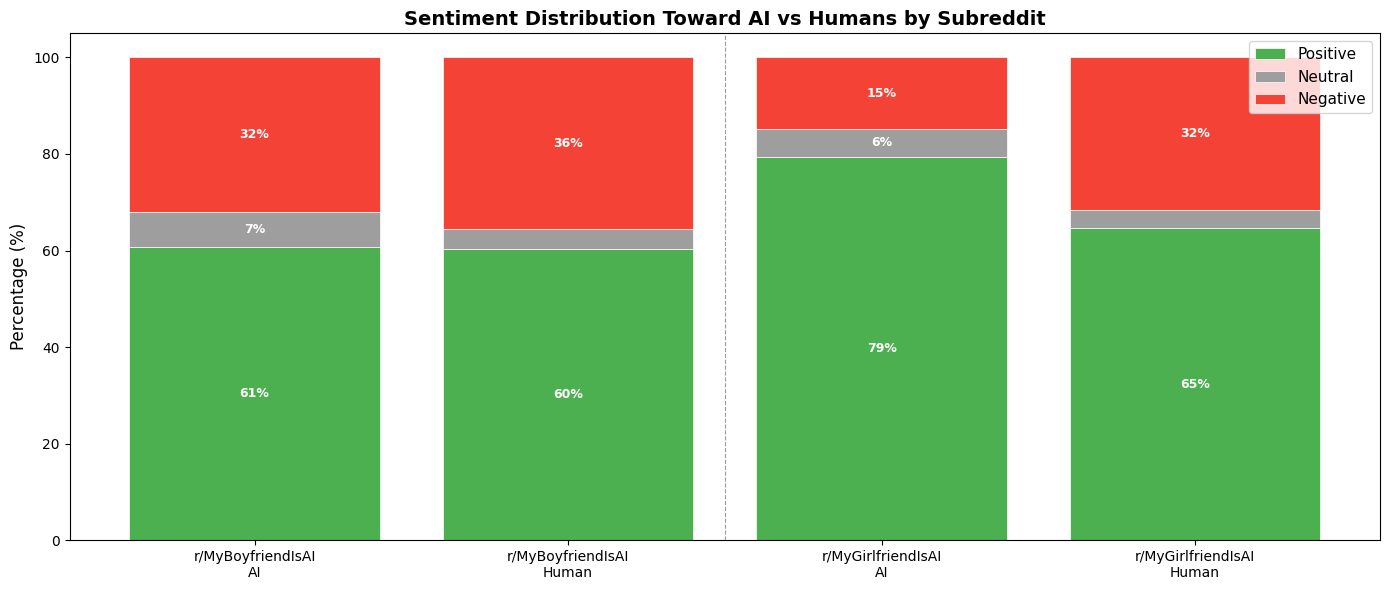

In [44]:
# ---------------------------------------------------------------------------
# Normalized stacked bar chart: sentiment proportions per (subreddit, aspect)
# ---------------------------------------------------------------------------

SENTIMENT_ORDER = ["positive", "neutral", "negative"]
SENTIMENT_COLORS = {"positive": "#4CAF50", "neutral": "#9E9E9E", "negative": "#F44336"}
ASPECT_LABELS = {"ai": "AI", "human": "Human"}

# Build a proportion table
prop_df = (
    df.groupby(["subreddit", "aspect", "sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER, fill_value=0)
)
# Normalize each row to percentages
prop_df = prop_df.div(prop_df.sum(axis=1), axis=0) * 100

# Create labels for x-axis: "r/ChatGPT\nAI", "r/ChatGPT\nHuman", ...
labels = []
for (sub, asp) in prop_df.index:
    labels.append(f"r/{sub}\n{ASPECT_LABELS.get(asp, asp)}")

fig, ax = plt.subplots(figsize=(14, 6))

bottoms = [0.0] * len(prop_df)
for sentiment in SENTIMENT_ORDER:
    values = prop_df[sentiment].values
    bars = ax.bar(
        range(len(labels)),
        values,
        bottom=bottoms,
        label=sentiment.capitalize(),
        color=SENTIMENT_COLORS[sentiment],
        edgecolor="white",
        linewidth=0.5,
    )
    # Add percentage labels inside bars
    for i, (v, b) in enumerate(zip(values, bottoms)):
        if v > 5:  # only label if segment is large enough
            ax.text(
                i, b + v / 2, f"{v:.0f}%",
                ha="center", va="center", fontsize=9, fontweight="bold", color="white",
            )
    bottoms = [b + v for b, v in zip(bottoms, values)]

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_ylim(0, 105)
ax.legend(loc="upper right", fontsize=11)
ax.set_title("Sentiment Distribution Toward AI vs Humans by Subreddit", fontsize=14, fontweight="bold")

# Add vertical separators between subreddits
for i in range(1, len(SUBREDDITS)):
    ax.axvline(x=i * 2 - 0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.4)

plt.tight_layout()
plt.show()

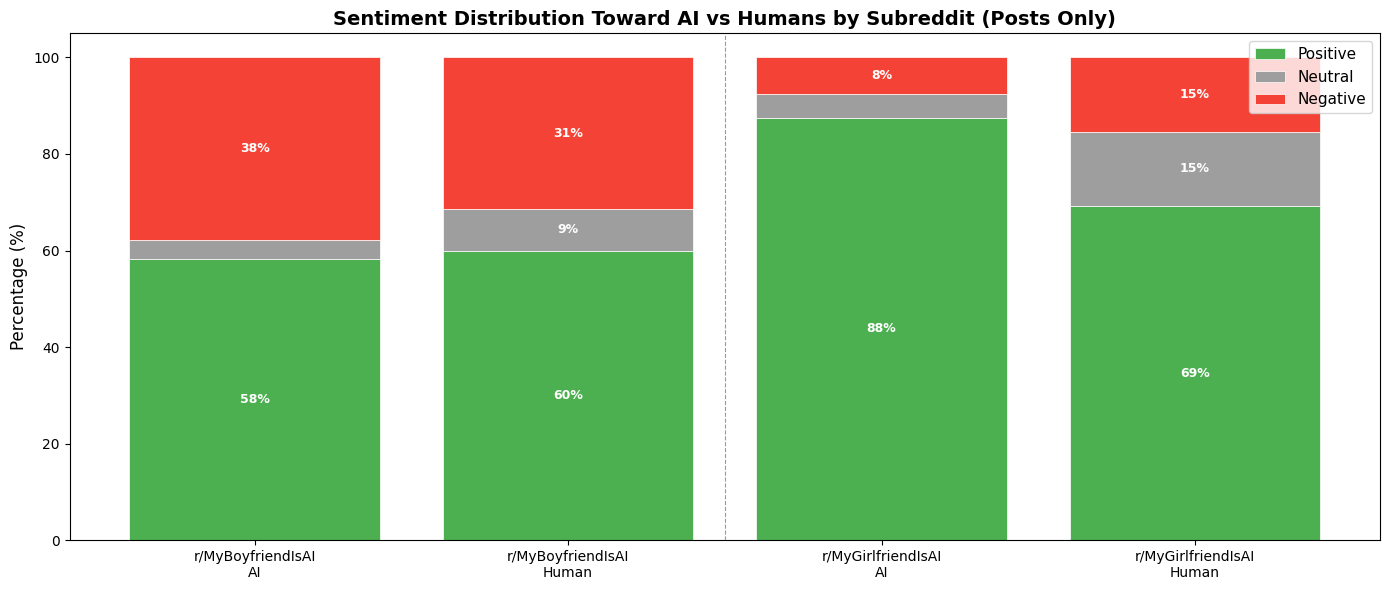

In [45]:
# ---------------------------------------------------------------------------
# Normalized stacked bar chart: posts only (no comments)
# ---------------------------------------------------------------------------

posts_df = df[df["source"] == "post"]

# Build a proportion table for posts only
prop_posts = (
    posts_df.groupby(["subreddit", "aspect", "sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER, fill_value=0)
)
prop_posts = prop_posts.div(prop_posts.sum(axis=1), axis=0) * 100

labels_posts = []
for (sub, asp) in prop_posts.index:
    labels_posts.append(f"r/{sub}\n{ASPECT_LABELS.get(asp, asp)}")

fig, ax = plt.subplots(figsize=(14, 6))

bottoms = [0.0] * len(prop_posts)
for sentiment in SENTIMENT_ORDER:
    values = prop_posts[sentiment].values
    ax.bar(
        range(len(labels_posts)),
        values,
        bottom=bottoms,
        label=sentiment.capitalize(),
        color=SENTIMENT_COLORS[sentiment],
        edgecolor="white",
        linewidth=0.5,
    )
    for i, (v, b) in enumerate(zip(values, bottoms)):
        if v > 5:
            ax.text(
                i, b + v / 2, f"{v:.0f}%",
                ha="center", va="center", fontsize=9, fontweight="bold", color="white",
            )
    bottoms = [b + v for b, v in zip(bottoms, values)]

ax.set_xticks(range(len(labels_posts)))
ax.set_xticklabels(labels_posts, fontsize=10)
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_ylim(0, 105)
ax.legend(loc="upper right", fontsize=11)
ax.set_title("Sentiment Distribution Toward AI vs Humans by Subreddit (Posts Only)", fontsize=14, fontweight="bold")

for i in range(1, len(SUBREDDITS)):
    ax.axvline(x=i * 2 - 0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.4)

plt.tight_layout()
plt.show()

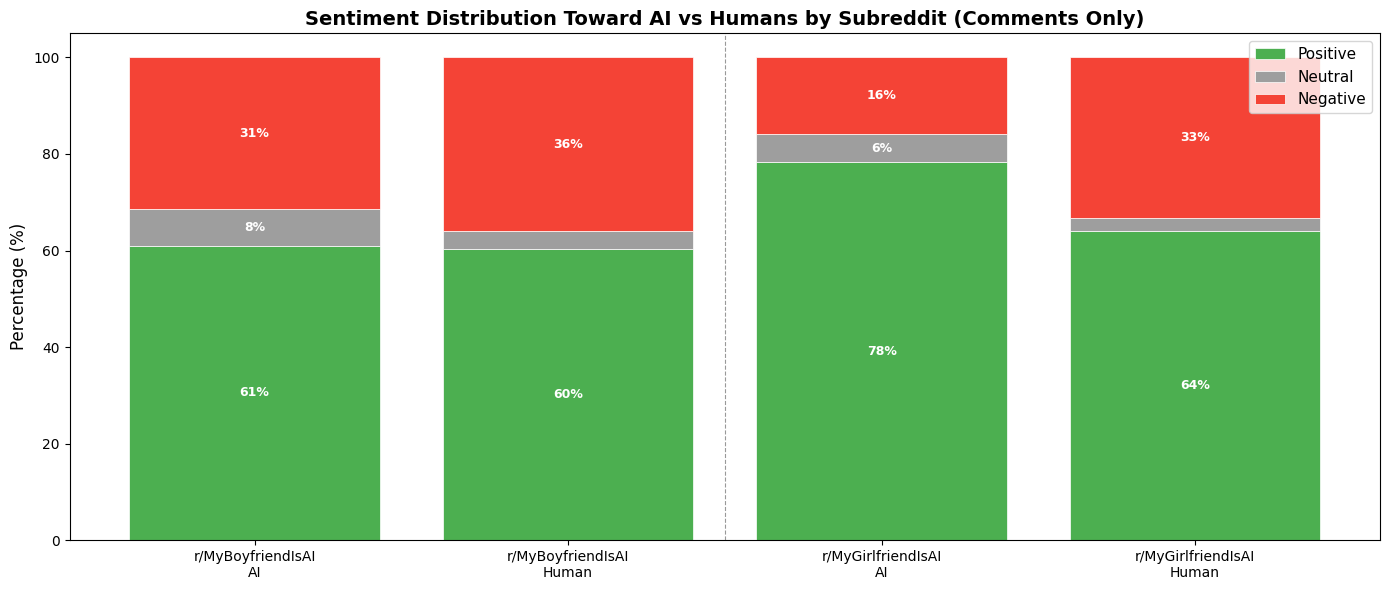

In [46]:
# ---------------------------------------------------------------------------
# Normalized stacked bar chart: comments only (no posts)
# ---------------------------------------------------------------------------

comments_df = df[df["source"] == "comment"]

# Build a proportion table for comments only
prop_comments = (
    comments_df.groupby(["subreddit", "aspect", "sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER, fill_value=0)
)
prop_comments = prop_comments.div(prop_comments.sum(axis=1), axis=0) * 100

labels_comments = []
for (sub, asp) in prop_comments.index:
    labels_comments.append(f"r/{sub}\n{ASPECT_LABELS.get(asp, asp)}")

fig, ax = plt.subplots(figsize=(14, 6))

bottoms = [0.0] * len(prop_comments)
for sentiment in SENTIMENT_ORDER:
    values = prop_comments[sentiment].values
    ax.bar(
        range(len(labels_comments)),
        values,
        bottom=bottoms,
        label=sentiment.capitalize(),
        color=SENTIMENT_COLORS[sentiment],
        edgecolor="white",
        linewidth=0.5,
    )
    for i, (v, b) in enumerate(zip(values, bottoms)):
        if v > 5:
            ax.text(
                i, b + v / 2, f"{v:.0f}%",
                ha="center", va="center", fontsize=9, fontweight="bold", color="white",
            )
    bottoms = [b + v for b, v in zip(bottoms, values)]

ax.set_xticks(range(len(labels_comments)))
ax.set_xticklabels(labels_comments, fontsize=10)
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_ylim(0, 105)
ax.legend(loc="upper right", fontsize=11)
ax.set_title("Sentiment Distribution Toward AI vs Humans by Subreddit (Comments Only)", fontsize=14, fontweight="bold")

for i in range(1, len(SUBREDDITS)):
    ax.axvline(x=i * 2 - 0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.4)

plt.tight_layout()
plt.show()

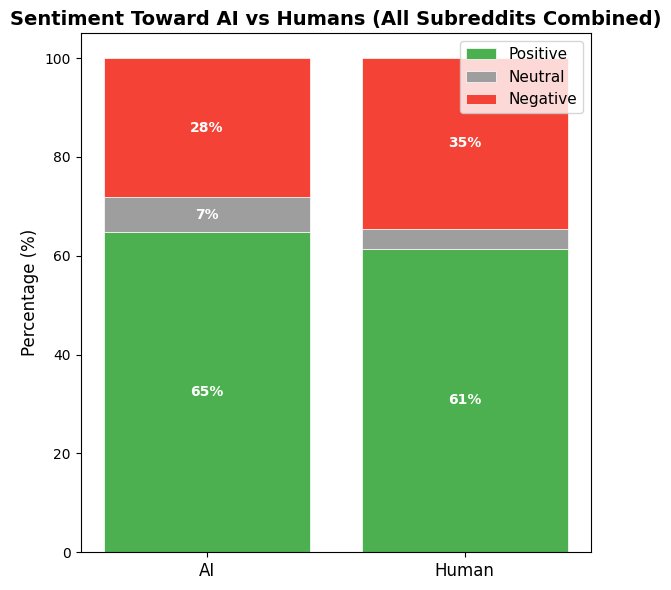

In [47]:
# ---------------------------------------------------------------------------
# Normalized stacked bar chart: all subreddits combined
# ---------------------------------------------------------------------------

# Build a proportion table grouped only by aspect (ignore subreddit)
prop_all = (
    df.groupby(["aspect", "sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER, fill_value=0)
)
prop_all = prop_all.div(prop_all.sum(axis=1), axis=0) * 100

labels_all = [ASPECT_LABELS.get(asp, asp) for asp in prop_all.index]

fig, ax = plt.subplots(figsize=(6, 6))

bottoms = [0.0] * len(prop_all)
for sentiment in SENTIMENT_ORDER:
    values = prop_all[sentiment].values
    ax.bar(
        range(len(labels_all)),
        values,
        bottom=bottoms,
        label=sentiment.capitalize(),
        color=SENTIMENT_COLORS[sentiment],
        edgecolor="white",
        linewidth=0.5,
    )
    for i, (v, b) in enumerate(zip(values, bottoms)):
        if v > 5:
            ax.text(
                i, b + v / 2, f"{v:.0f}%",
                ha="center", va="center", fontsize=10, fontweight="bold", color="white",
            )
    bottoms = [b + v for b, v in zip(bottoms, values)]

ax.set_xticks(range(len(labels_all)))
ax.set_xticklabels(labels_all, fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_ylim(0, 105)
ax.legend(loc="upper right", fontsize=11)
ax.set_title("Sentiment Toward AI vs Humans (All Subreddits Combined)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()